In [1]:
import zipfile

# Open the zip file
with zipfile.ZipFile('titanic.zip', 'r') as z:
    # Print the list of all files inside
    print(z.namelist())

['gender_submission.csv', 'test.csv', 'train.csv']


In [2]:
import pandas as pd
import zipfile

# 1. Define the zip and the specific file you want
zip_name = 'titanic.zip'
file_inside = 'test.csv' # Use the exact name from the list above

# 2. Use a "with" statement to open it safely
with zipfile.ZipFile(zip_name, 'r') as z:
    with z.open(file_inside) as f:
        df = pd.read_csv(f)
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [4]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [6]:
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [8]:
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        418 non-null    object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [10]:
with zipfile.ZipFile('titanic.zip', 'r') as z:
    with z.open('train.csv') as f:
        train_df = pd.read_csv(f)
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
print(train_df['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [12]:
# Group by Passenger Class and calculate the average of 'Survived'
print(train_df.groupby('Pclass')['Survived'].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


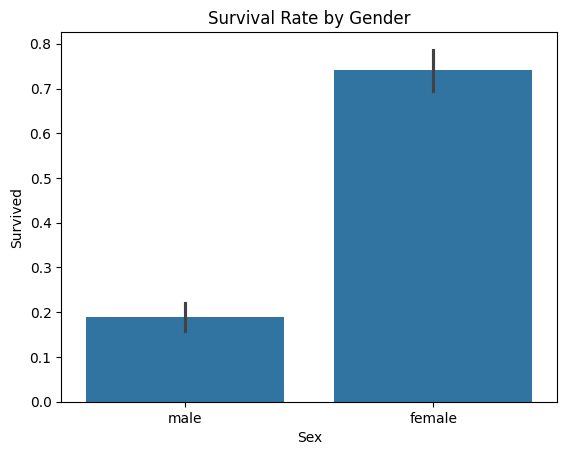

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a simple bar plot
sns.barplot(x='Sex', y='Survived', data=train_df)
plt.title('Survival Rate by Gender')
plt.show()

In [14]:
# This creates a simple table showing Counts
pd.crosstab(train_df['Pclass'], train_df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


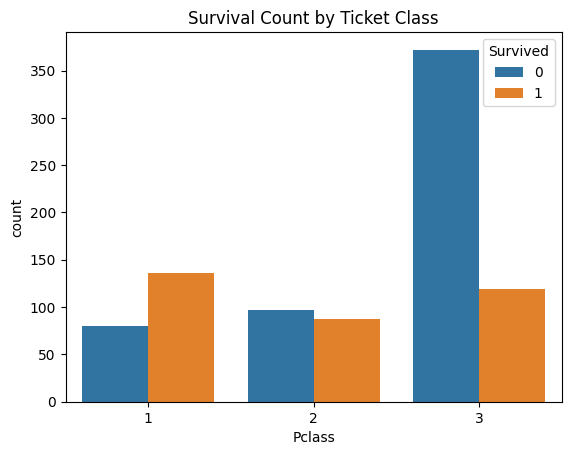

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize survival counts by class
sns.countplot(x='Pclass', hue='Survived', data=train_df)
plt.title('Survival Count by Ticket Class')
plt.show()

In [16]:
print(train_df.groupby('Pclass')['Age'].mean())

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


In [17]:
print(train_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [18]:
# 1. Extract Titles (Mr, Mrs, Miss, etc.)
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 2. Fill missing Age with the median age of that specific Title
train_df['Age'] = train_df['Age'].fillna(train_df.groupby('Title')['Age'].transform('median'))

In [19]:
# Show the columns we just manipulated
train_df[['Name', 'Title', 'Age']].head(10)

,Name,Title,Age
0,"Braund, Mr. Owen Harris",Mr,22.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,38.0
2,"Heikkinen, Miss. Laina",Miss,26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,35.0
4,"Allen, Mr. William Henry",Mr,35.0
5,"Moran, Mr. James",Mr,30.0
6,"McCarthy, Mr. Timothy J",Mr,54.0
7,"Palsson, Master. Gosta Leonard",Master,2.0
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,27.0
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,14.0


In [20]:
# Show only passengers with the title 'Master' 
# (You'll notice many now have the same median age)
train_df[train_df['Title'] == 'Master'][['Name', 'Age']].head()

,Name,Age
7,"Palsson, Master. Gosta Leonard",2.0
16,"Rice, Master. Eugene",2.0
50,"Panula, Master. Juha Niilo",7.0
59,"Goodwin, Master. William Frederick",11.0
63,"Skoog, Master. Harald",4.0


In [21]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

# Check the survival rate by family size
print(train_df.groupby('FamilySize')['Survived'].mean())

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


In [22]:
# Convert Sex to 0 and 1
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})

# Check the first few rows to see the change
train_df[['Name', 'Sex', 'Age', 'FamilySize']].head()

,Name,Sex,Age,FamilySize
0,"Braund, Mr. Owen Harris",0,22.0,2
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,2
2,"Heikkinen, Miss. Laina",1,26.0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,2
4,"Allen, Mr. William Henry",0,35.0,1


In [23]:
# Save the cleaned training data to a new CSV file in your folder
train_df.to_csv('titanic_train_cleaned.csv', index=False)

# Save the cleaned test data too
df.to_csv('titanic_test_cleaned.csv', index=False)

In [24]:
# Check if any missing values remain
print("Missing ages remaining:", train_df['Age'].isnull().sum())

Missing ages remaining: 0


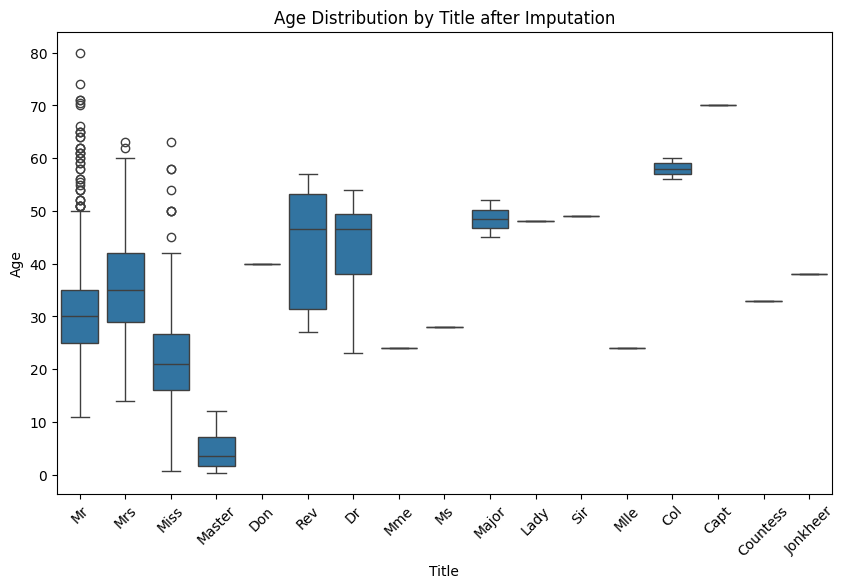

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='Title', y='Age', data=train_df)
plt.title('Age Distribution by Title after Imputation')
plt.xticks(rotation=45)
plt.show()

In [26]:
# Calculate survival rate for each title
title_survival = train_df.groupby('Title')['Survived'].mean().sort_values(ascending=False)
print(title_survival)

Title
Countess    1.000000
Ms          1.000000
Lady        1.000000
Mme         1.000000
Mlle        1.000000
Sir         1.000000
Mrs         0.792000
Miss        0.697802
Master      0.575000
Major       0.500000
Col         0.500000
Dr          0.428571
Mr          0.156673
Capt        0.000000
Don         0.000000
Jonkheer    0.000000
Rev         0.000000
Name: Survived, dtype: float64


In [27]:
# First, fill the 2 missing values with the most common port ('S')
train_df['Embarked'] = train_df['Embarked'].fillna('S')

# Map the letters to numbers
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Verify the change
print(train_df[['Embarked', 'Pclass', 'Survived']].head())

   Embarked  Pclass  Survived
0         0       3         0
1         1       1         1
2         0       3         1
3         0       1         1
4         0       3         0


In [28]:
# Compare survival rates based on the Port
print(train_df.groupby('Embarked')['Survived'].mean())

Embarked
0    0.339009
1    0.553571
2    0.389610
Name: Survived, dtype: float64


In [29]:
# Select the numeric columns we want to compare
# We exclude PassengerId because it's just a random serial number
cols_to_compare = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
corr_matrix = train_df[cols_to_compare].corr()

# Show the raw numbers
corr_matrix

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Survived,1.000000,-0.338481,0.543351,-0.078816,-0.035322,0.081629,0.257307,0.106811
Pclass,-0.338481,1.000000,-0.131900,-0.354005,0.083081,0.018443,-0.549500,0.045702
Sex,0.543351,-0.131900,1.000000,-0.104820,0.114631,0.245489,0.182333,0.116569
Age,-0.078816,-0.354005,-0.104820,1.000000,-0.265602,-0.188122,0.097944,-0.030277
SibSp,-0.035322,0.083081,0.114631,-0.265602,1.000000,0.414838,0.159651,-0.059961
Parch,0.081629,0.018443,0.245489,-0.188122,0.414838,1.000000,0.216225,-0.078665
Fare,0.257307,-0.549500,0.182333,0.097944,0.159651,0.216225,1.000000,0.062142
Embarked,0.106811,0.045702,0.116569,-0.030277,-0.059961,-0.078665,0.062142,1.000000


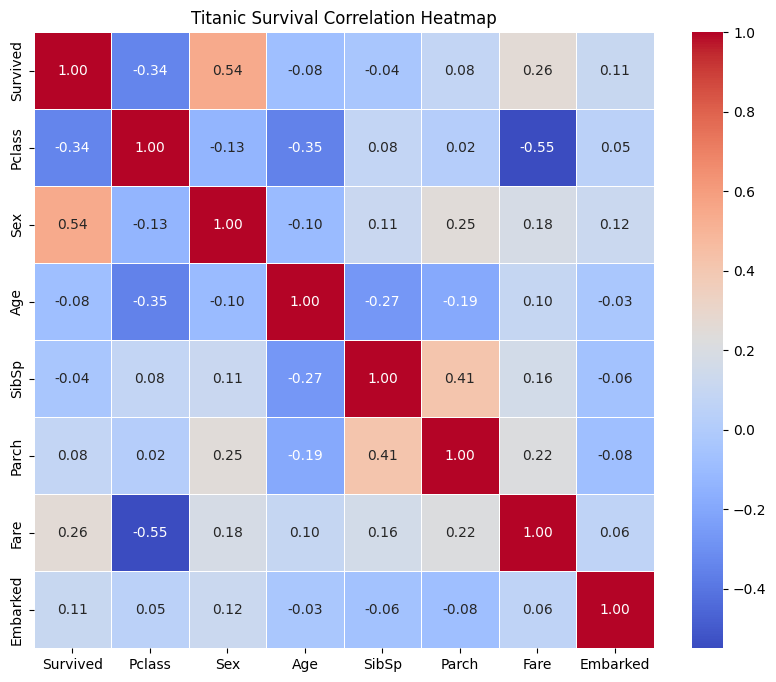

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# 'annot=True' puts the numbers inside the squares
# 'cmap=coolwarm' makes positives Red and negatives Blue
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Titanic Survival Correlation Heatmap')
plt.show()

In [31]:
# 1. Reach back into the zip to get the 'fresh' column
with zipfile.ZipFile('titanic.zip', 'r') as z:
    with z.open('train.csv') as f:
        temp_df = pd.read_csv(f)
        train_df['Sex'] = temp_df['Sex']

# 2. Now perform the map ONCE
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})

# 3. Final Check - It should be False and show 0s/1s
print("Any NaNs now?:", train_df['Sex'].isnull().any())
print(train_df['Sex'].head())

Any NaNs now?: False
0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64


In [32]:
# Show the percentage of survival for 0 (Male) vs 1 (Female)
print(train_df.groupby('Sex')['Survived'].mean())

Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64


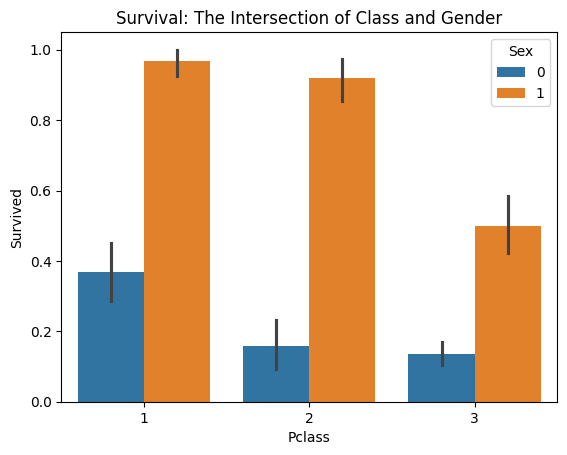

In [33]:
# This shows how Sex and Class worked together
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train_df)
plt.title('Survival: The Intersection of Class and Gender')
plt.show()

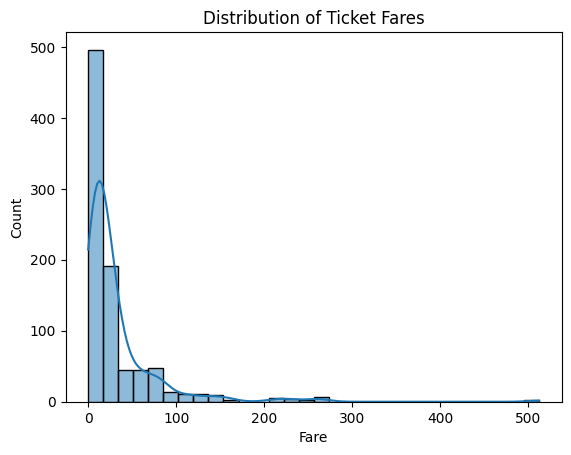

In [34]:
# See how the ticket prices are distributed
sns.histplot(train_df['Fare'], bins=30, kde=True)
plt.title('Distribution of Ticket Fares')
plt.show()

In [35]:
# Save your fresh, today-cleaned data
train_df.to_csv('titanic_train_V2_April9.csv', index=False)

print("Success! You now have a new file that includes your Title-based imputation.")

Success! You now have a new file that includes your Title-based imputation.


In [36]:
import numpy as np
# 1. Load the raw test data from your zip
with zipfile.ZipFile('titanic.zip', 'r') as z:
    with z.open('test.csv') as f:
        test_df = pd.read_csv(f)

# 2. Apply the SAME cleaning steps you did for Train
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df['Embarked'] = test_df['Embarked'].fillna('S').map({'S': 0, 'C': 1, 'Q': 2})

# 3. Handle the Missing Age (Using the Title Logic)
test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_df['Age'] = test_df['Age'].fillna(test_df.groupby('Title')['Age'].transform('median'))

# 4. Handle the one missing 'Fare' in the test set (Fill with median)
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['Fare_log'] = test_df['Fare'].apply(np.log1p)

# 5. Save it as your new version
test_df.to_csv('titanic_test_V2_April9.csv', index=False)